# Structure Diagram and Dynamical Portraits
Both draw from ''DYNAMICS AND TRANSIT VARIATIONS OF RESONANT EXOPLANETS'' from David Nesvorný and David Vokrouhlický, and similar work was conducted for TOI-2022 by Trifonov et al. 2021

In [1]:
import os
import sys
currdir = os.getcwd()
datadir = lambda file: f'{currdir}/data/{file}'
sysdir = lambda file: datadir(f'systems/{file}')
savedir = lambda file: f'{currdir}/figures/{file}'
import numpy as np
import pandas as pd

sys.path.insert(0, currdir)
import functionalities.general as gen
import functionalities.mmrdiagram as mm
import functionalities.reboundfuncs as re

## 2:1 MMR Structure Diagram
The class is created such that we can reuse it to create multiple different iterations with a different scatter. Below, from top to bottom:
- The static base template as given by Nesvorný & Vokrouhlický 2016.
- The scatter of our systems with their values within the threshold of $\Psi\sin(\psi)\sim$ 0 (i.e the diagram cross-section values which are the closest in time to the parameter values given in their literature).
- System scatters over time for 5000 years as demonstrated by (4)characterise.ipynb

For the cell below, we are loading in the data generated by (4)characterise.ipynb. What is significant is that the systems evolve across the whole diagram over time, however, we take the cross-section at $\Psi\sin(\psi)\sim$ 0 because that is how the equilibrium points and the resonant regimes are defined. Given a different value of $\Psi\sin(\psi)$, the location of the equilibrium points and libration regime will shift, as denoted in the contour plots below.

In [2]:
sysdfs = []
scatterdata = []
initialscatter = []
lenstr = '(5000)'
sysnames = ['TOI-4504', 'GJ-876', 'TOI-216', 'Kepler-9', 'HD-73526', 'HD-82943']

for i, sysname in enumerate(sysnames):
    fn = [fn for fn in os.listdir(sysdir('')) if f'{sysname}{lenstr}' in fn]
    if fn == '': continue
    df = pd.read_csv(sysdir(*fn))
    sysdfs.append(df)
    zerodf = df[np.abs(np.sin(df.psi)) < 0.01]
    sysvals = np.array([zerodf.delta, mm.Psifac(zerodf.Psi, zerodf.psi)])
    scatterdata.append(sysvals)
    initialscatter.append(sysvals[:, 0])
    # initialscatter.append([df.delta[0], mm.Psifac(df.Psi, df.psi)[0]])

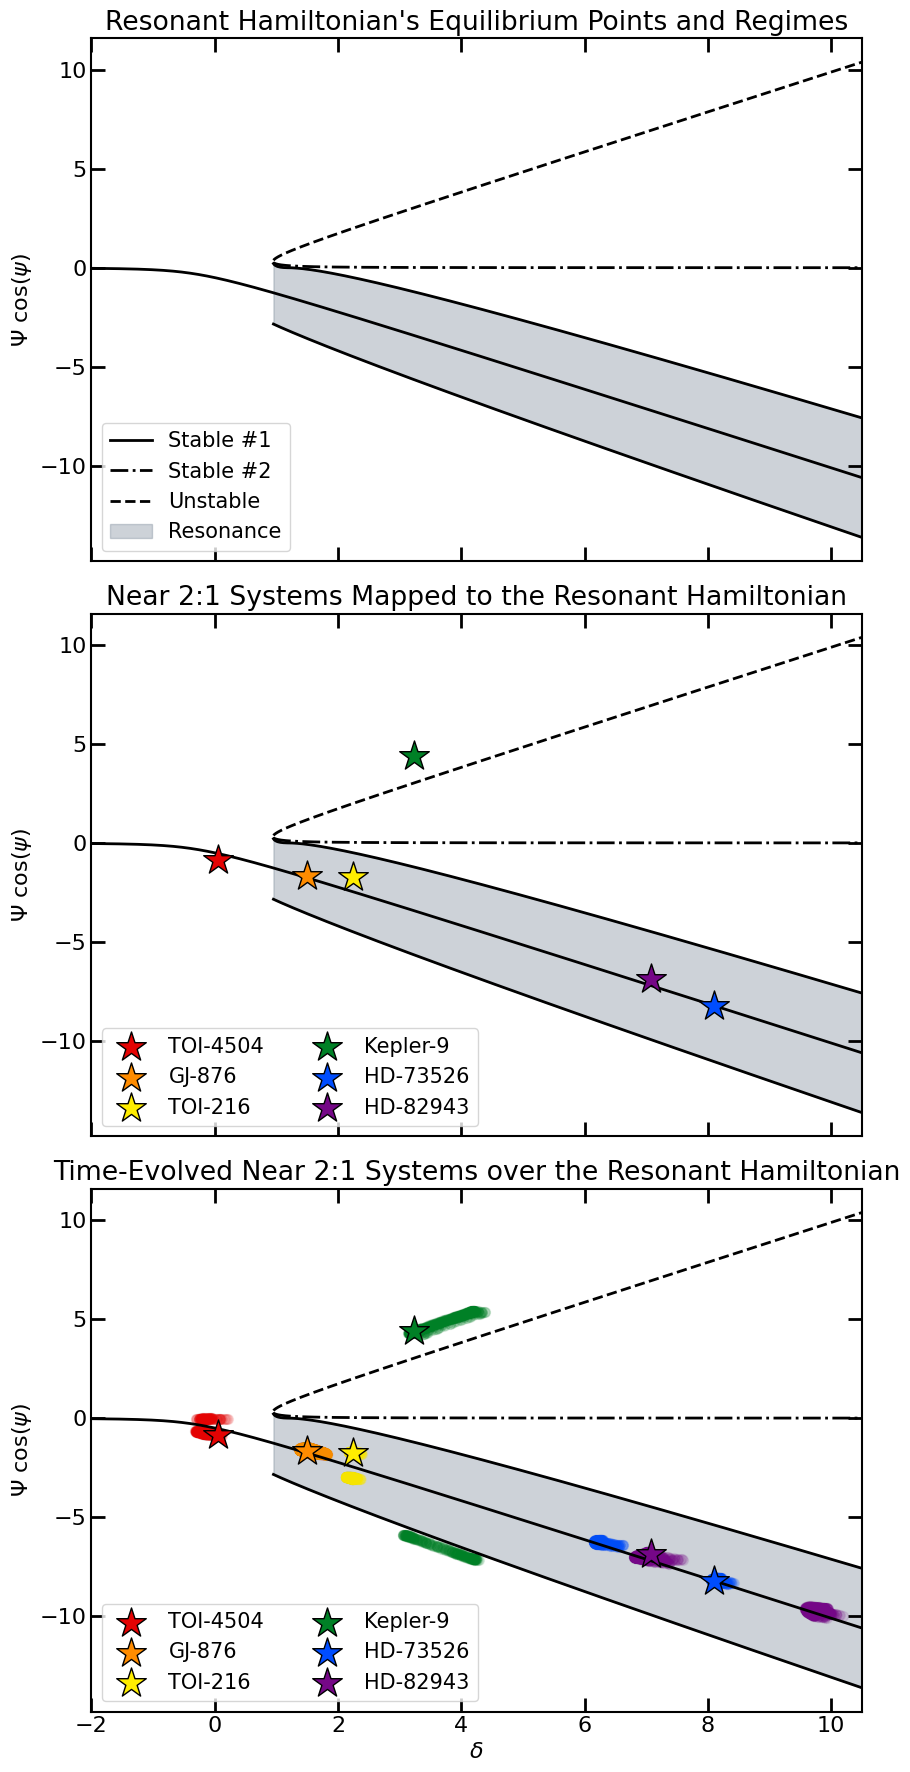

In [3]:
sc = mm.StructureDiagram()
sc.deltamax = 10.5
sc.set_labels = False
sc.legendict = {'loc': 'lower left', 'fontsize': 15, 'show': True}
fig, axs = gen.setupPlots((9, 18), row=3, col=1, logscale=0, sharex=True, sharey=True)
axs[0], _ = sc.scatterdiagram(axs[0])
axs[0].set_title('Resonant Hamiltonian\'s Equilibrium Points and Regimes')

sc.legendict = {'loc': 'lower left', 'fontsize': 15, 'ncols':2, 'show': False}
sc.sysmarkers = lambda colour, label: {'marker': '*', 's': 500, 'zorder': 15, \
                'edgecolor': 'black', 'color': colour, 'label': label}
sc.reinitialise(initialscatter, sysnames)
axs[1], _ = sc.scatterdiagram(axs[1])
handles, labels = axs[1].get_legend_handles_labels()
syshandles = np.array(handles, dtype=object)[np.isin(labels, sysnames)]
axs[1].legend(syshandles, sysnames, **sc.legendict)
axs[1].set_title('Near 2:1 Systems Mapped to the Resonant Hamiltonian')

axs[2], _ = sc.scatterdiagram(axs[2])
sc.sysmarkers = lambda colour, label: {'marker': 'o', 's': 50, 'zorder': 5, \
                'alpha': 0.1, 'color': colour, 'edgecolor': colour, 'label': label}
sc.reinitialise(scatterdata, sysnames)
axs[2], _ = sc.scattersys(axs[2])
axs[2].legend(syshandles, sysnames, **sc.legendict)
axs[2].set_title('Time-Evolved Near 2:1 Systems over the Resonant Hamiltonian')

for ax in axs: ax.set_ylabel(r'$\Psi$ cos($\psi$)')
axs[-1].set_xlabel(r'$\delta$')

fig.tight_layout()
fig.show()

## Dynamical Portraits
i.e Figure 5 from N&V 2016. We label the three equiibrium points through calculating the equilibrium points of the resonant Hamiltonian unless the separatrix is not present, if so, there remains only one equilibrium point. The separatrix is indicated in *bold*; this is done through the ax.contour functionality by specifying the energy level of the separatrix.

Because different $\delta$ shift the contour plots, we demonstrate a range of $\delta$ for TOI 4504 and HD 82943. The former is notable because it lacks a separatrix but remains in libration (its evolution does not encompass the origin); the latter because its evolution spans a wide range of $\delta$ and is hence instructive. Subsequently, the entire scatter for the time-evolution is given for the time-averaged delta.

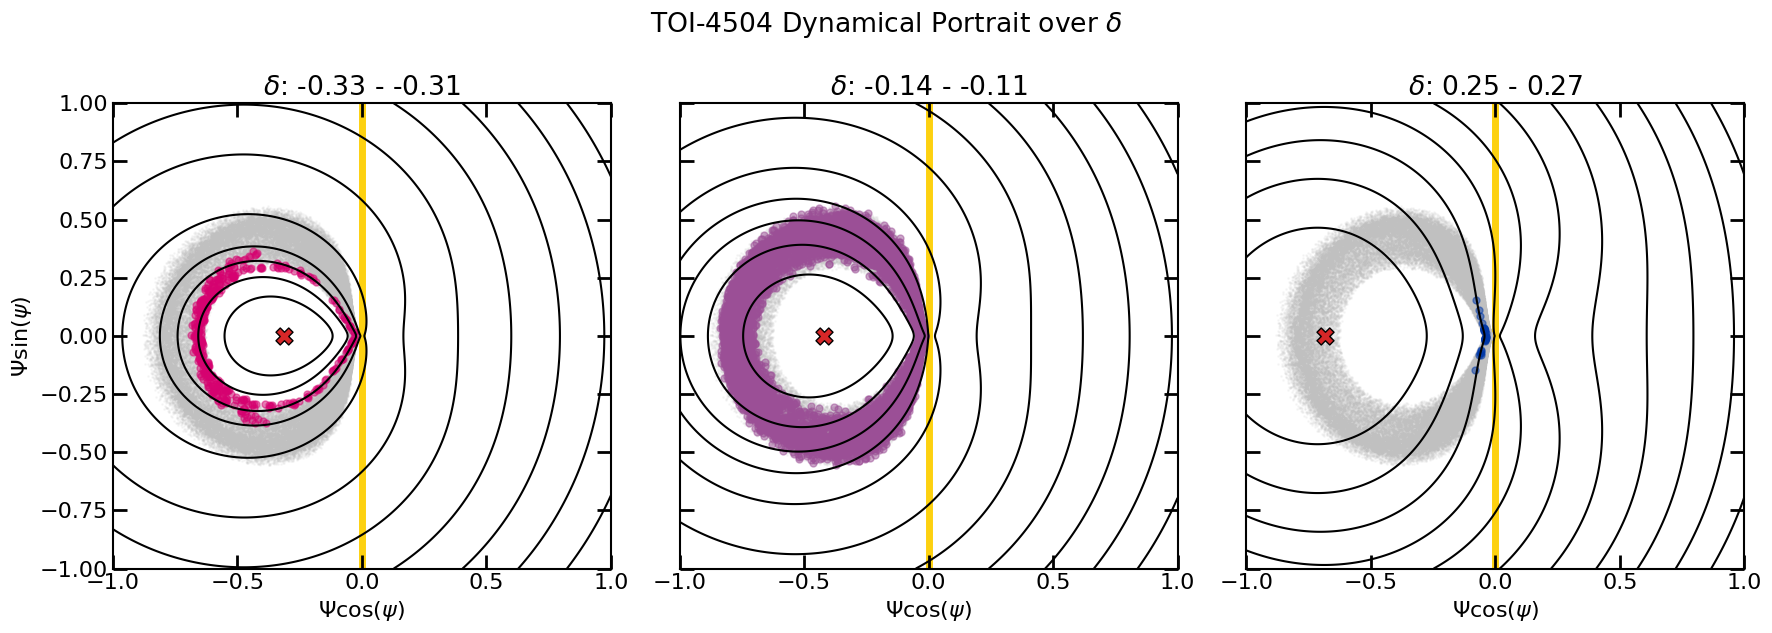

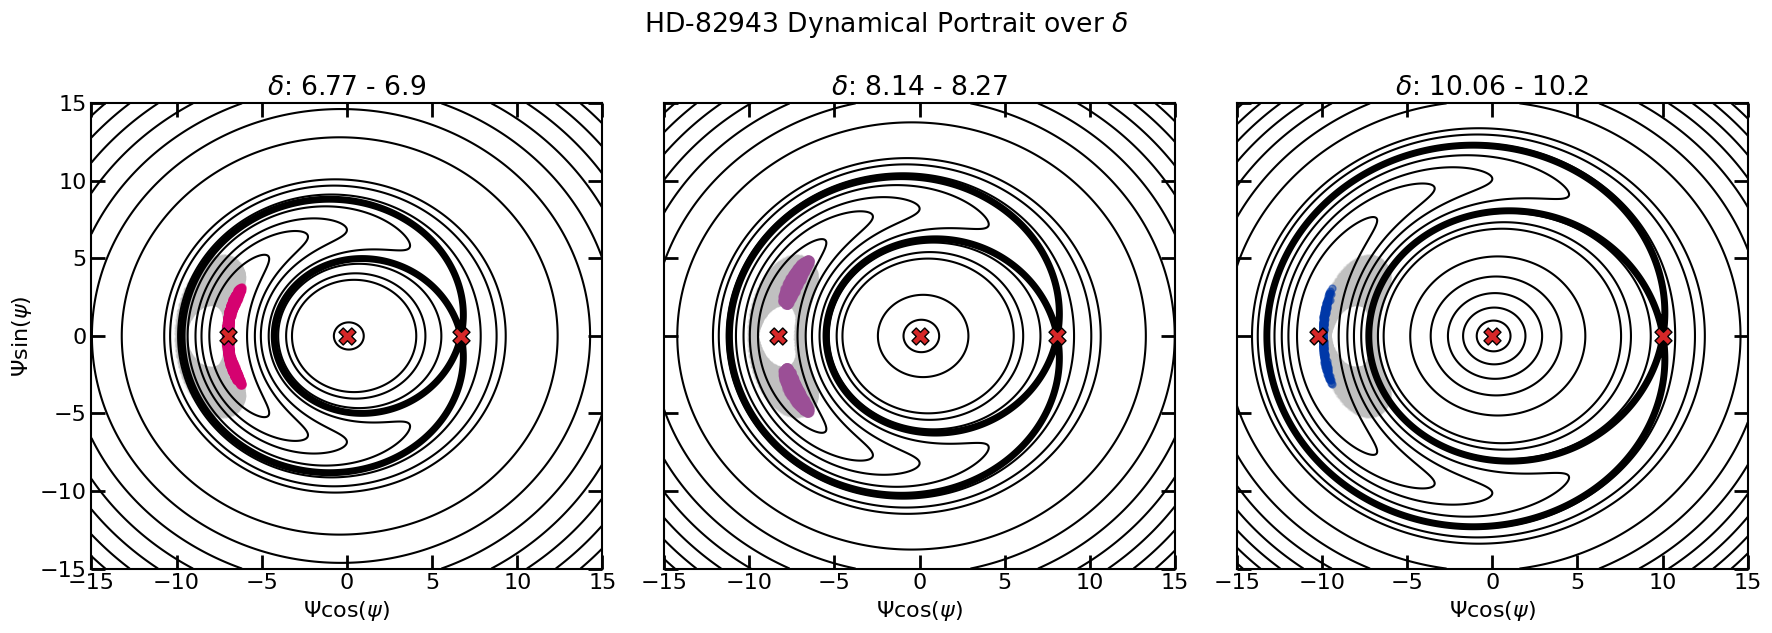

In [4]:
toi4504df = sysdfs[np.where(np.isin(sysnames, 'TOI-4504'))[0][0]]
t4504contour = mm.ContourParameters('TOI-4504')
t4504contour.axbounds = 1
t4504contour.efunc = lambda Hc: np.array([*np.linspace(np.min(Hc), -0.25, 8), *np.linspace(0, np.max(Hc), 5)])
# t4504contour.contour = dict(colors='black')
fig, axs = gen.setupPlots((18, 6.5), row=1, col=3, logscale=0, sharex=True, sharey=True)
axs = t4504contour.contourportrait3(axs, toi4504df)
for ax in axs: ax.axvline(x=0, color='#fdd110', lw=5, zorder=0)
fig.suptitle(r'TOI-4504 Dynamical Portrait over $\delta$')
fig.tight_layout()
fig.show()

hd8df = sysdfs[np.where(np.isin(sysnames, 'HD-82943'))[0][0]]
hd8contour = mm.ContourParameters('HD-82943')
hd8contour.axbounds = 15
hd8contour.trixlabel = dict(show=False)
hd8contour.efunc = lambda Hc: np.array([*np.linspace(np.min(Hc), -10.5, 9), *np.linspace(-8, -2, 3), *np.linspace(0, np.max(Hc), 4)])
fig, axs = gen.setupPlots((18, 6.5), row=1, col=3, logscale=0, sharex=True, sharey=True)
axs = hd8contour.contourportrait3(axs, hd8df)
fig.suptitle(r'HD-82943 Dynamical Portrait over $\delta$')
fig.tight_layout()
fig.show()

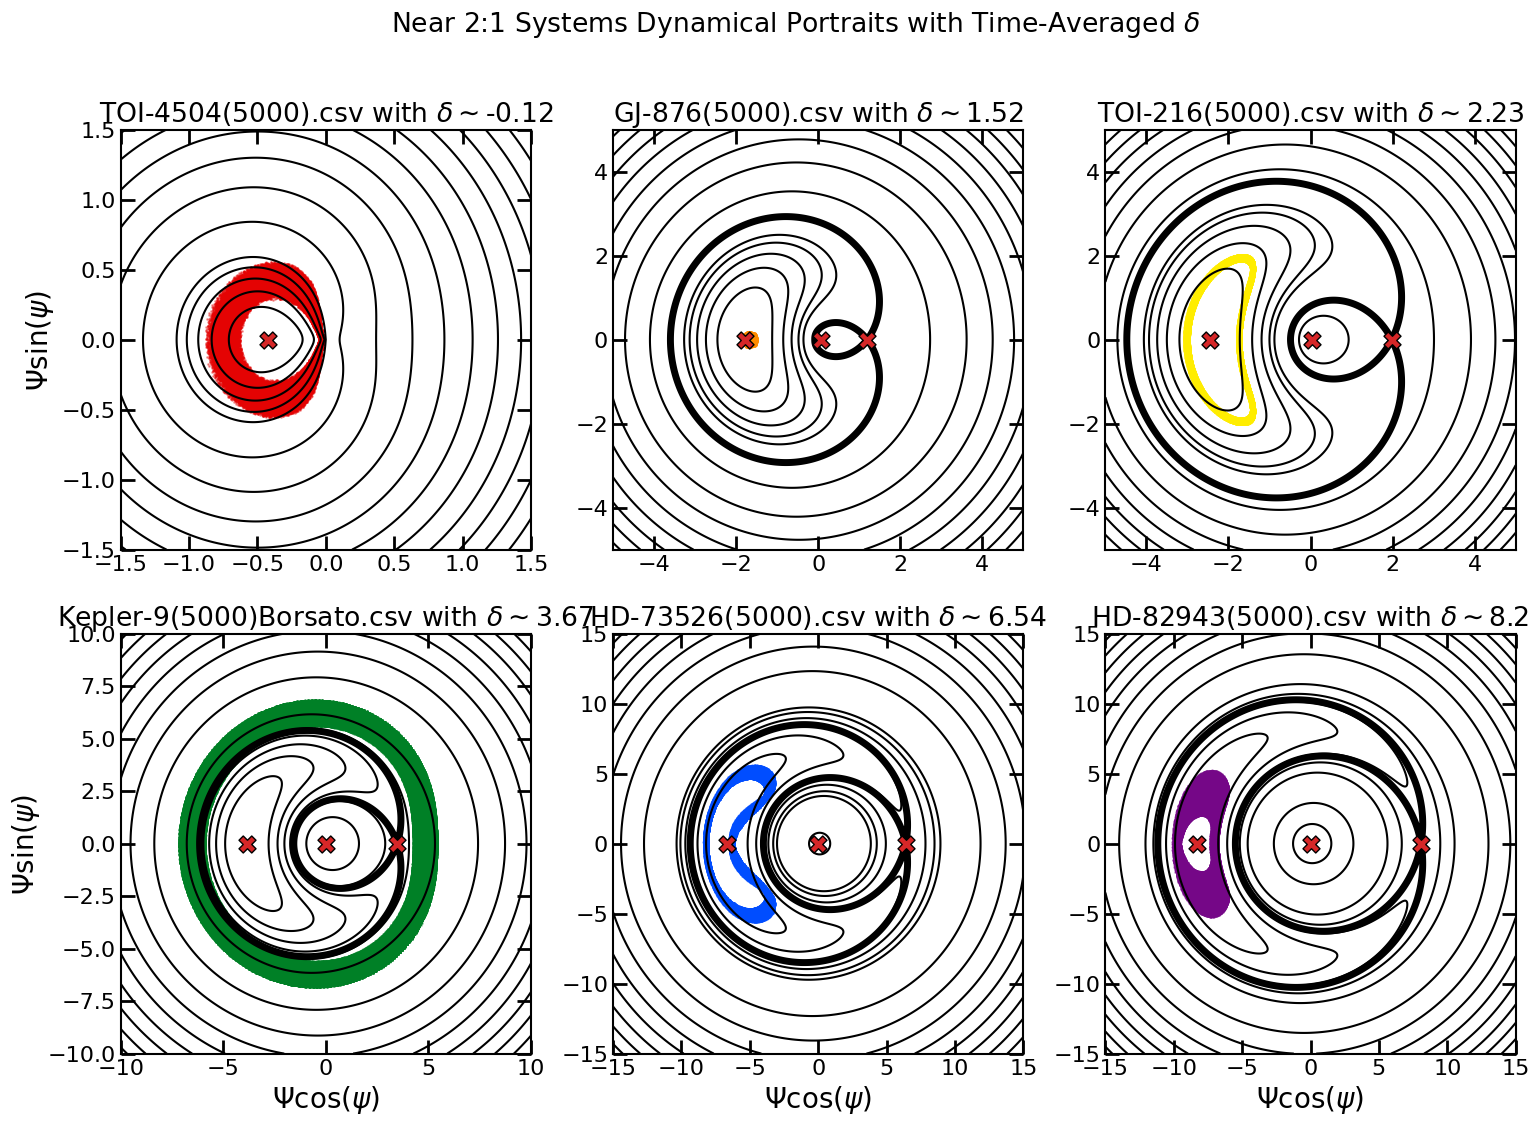

In [5]:
dpars = mm.DiagramParameters([], sysnames)
axbounds = [1.5, 5, 5, 10, 15, 15]
efuncs = [lambda Hc:  np.array([*np.linspace(np.min(Hc), -0.5, 11), *np.linspace(0, np.max(Hc), 6)]), \
          lambda Hc: np.array([*np.linspace(np.min(Hc), -0.5, 11), *np.linspace(-0.1, np.max(Hc), 5)]), \
          lambda Hc: np.array([*np.linspace(np.min(Hc), -0.5, 11), *np.linspace(-0.1, np.max(Hc), 5)]), \
          lambda Hc: np.array([*np.linspace(np.min(Hc), -6, 10), *np.linspace(-3, np.max(Hc), 6)]), \
          lambda Hc: np.array([*np.linspace(np.min(Hc), -10, 10), *np.linspace(-8, np.max(Hc), 6)]), \
          lambda Hc: np.array([*np.linspace(np.min(Hc), -10, 10), *np.linspace(-6, np.max(Hc), 5)])]

fig, axs = gen.setupPlots((18,12), col=3, row=2, logscale=0)
axarr = axs.flatten()

for i, sysname in enumerate(sysnames):
    fn = [fn for fn in os.listdir(sysdir('')) if f'{sysname}{lenstr}' in fn]
    if fn == '': continue
    df = pd.read_csv(sysdir(*fn))

    con = mm.ContourParameters(*fn)
    con.alldatamarker = dict(color=dpars.colours[i], s=1, alpha=0.35)
    con.set_labels = False
    con.axbounds = axbounds[i]
    con.efunc = efuncs[i]
    con.trixlabel = dict(show=False)
    axarr[i] = con.contourportrait(axarr[i], df)

for ax in axs[-1, :]: ax.set_xlabel(r'$\Psi \cos(\psi)$', fontsize=20)
for ax in axs[:, 0]: ax.set_ylabel(r'$\Psi \sin(\psi)$', fontsize=20)
fig.suptitle(r'Near 2:1 Systems Dynamical Portraits with Time-Averaged $\delta$')
fig.show()